# This Notebook Aims to Use Binary Logistic Regression

## Importing

In [1]:
from pathlib import Path
import sys
root= Path.cwd().parent
sys.path.append(str(root))

from src.graph import gradient_descent_tuning, gradient_descent_convergence
from src.classification import gradient_descent, logistic_function, compute_cost
import pandas as pd
import numpy as np
import pickle

In [2]:
training_data = pd.read_csv("../data/classification/binary/training_data.csv")
testing_data = pd.read_csv("../data/classification/binary/testing_data.csv")

In [3]:
training_X= pd.concat([ training_data.iloc[:, 0:3], training_data.iloc[:, 4:]], axis=1 )
training_targets = training_data.iloc[:, 3].to_numpy()

testing_X= pd.concat( [testing_data.iloc[:, 0:3], testing_data.iloc[:, 4:]], axis=1 )
testing_targets = testing_data.iloc[:, 3].to_numpy()

## Parameter Tuning Alpha and Epsilon

### Tuning Alpha

iteration #1 starts now
Converged at iteration 30893.
iteration #2 starts now
Converged at iteration 30404.
iteration #3 starts now
Converged at iteration 29920.
iteration #4 starts now
Converged at iteration 29440.
iteration #5 starts now
Converged at iteration 28964.
iteration #6 starts now
Converged at iteration 28494.
iteration #7 starts now
Converged at iteration 28028.
iteration #8 starts now
Converged at iteration 27568.
iteration #9 starts now
Converged at iteration 27114.
iteration #10 starts now
Converged at iteration 26665.
iteration #11 starts now
Converged at iteration 26223.
iteration #12 starts now
Converged at iteration 25786.
iteration #13 starts now
Converged at iteration 25356.
iteration #14 starts now
Converged at iteration 24931.
iteration #15 starts now
Converged at iteration 24514.
iteration #16 starts now
Converged at iteration 24102.
iteration #17 starts now
Converged at iteration 23697.
iteration #18 starts now
Converged at iteration 23298.
iteration #19 start

{np.float64(0.001): {'cost': 0.2882936955897831, 'time': 10510.151700000279},
 np.float64(0.0010437290924388725): {'cost': 0.2874709642522501,
  'time': 11887.029299978167},
 np.float64(0.0010893704184032726): {'cost': 0.286664047749713,
  'time': 11759.046399965882},
 np.float64(0.0011370075981298026): {'cost': 0.28587376862285246,
  'time': 11404.129600035958},
 np.float64(0.0011867279084921212): {'cost': 0.2850999378243403,
  'time': 10970.384299987927},
 np.float64(0.001238622442902363): {'cost': 0.28434035404657987,
  'time': 11067.333000013605},
 np.float64(0.0012927862782049014): {'cost': 0.28359680347507804,
  'time': 11351.303599891253},
 np.float64(0.0013493186488682295): {'cost': 0.2828670608227894,
  'time': 10030.285399989225},
 np.float64(0.001408323128794083): {'cost': 0.2821508901671641,
  'time': 10223.025600076653},
 np.float64(0.0014699078210769216): {'cost': 0.2814490464064027,
  'time': 10713.176099932753},
 np.float64(0.001534185556061416): {'cost': 0.280759277092

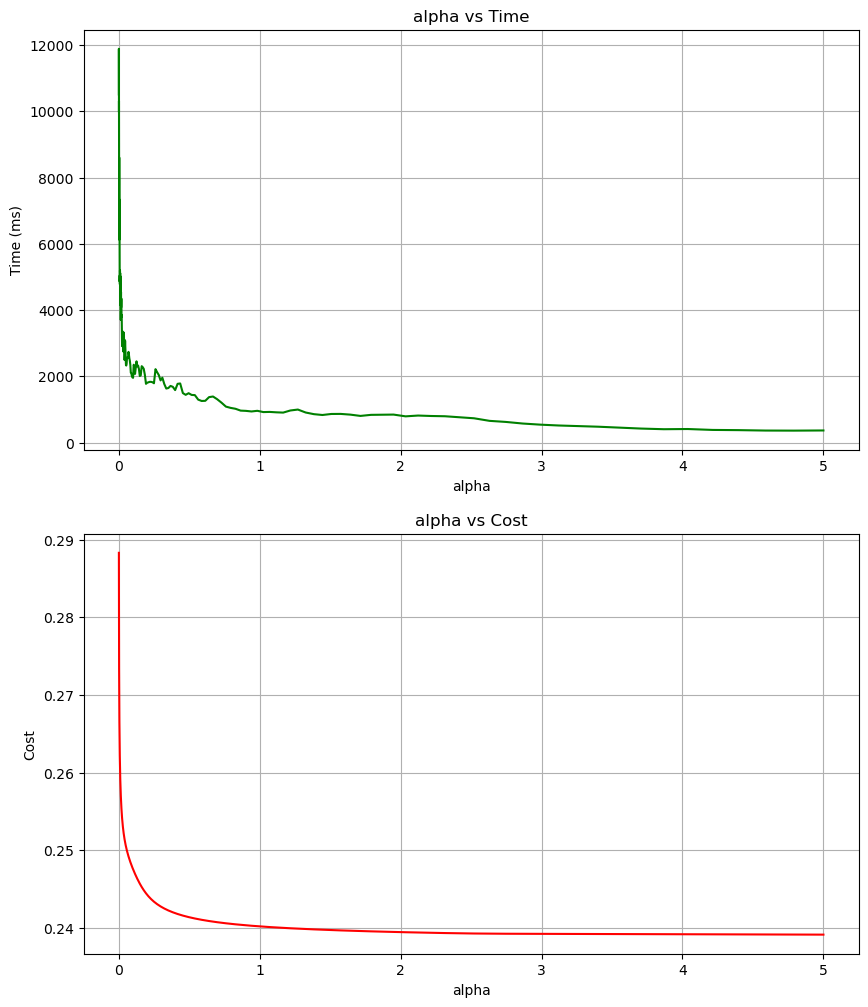

In [ ]:
gradient_descent_tuning(training_X, training_targets, np.geomspace(0.001, 5, num=200), 1e-6, 'A', gradient_descent, 50000 )

### Tuning Epsilon

iteration #1 starts now
Converged at iteration 20.
iteration #2 starts now
Converged at iteration 33.
iteration #3 starts now
Converged at iteration 55.
iteration #4 starts now
Converged at iteration 90.
iteration #5 starts now
Converged at iteration 155.
iteration #6 starts now
Converged at iteration 318.
iteration #7 starts now
Converged at iteration 581.
iteration #8 starts now
Converged at iteration 897.
iteration #9 starts now
Converged at iteration 1312.
iteration #10 starts now
Converged at iteration 1568.
iteration #11 starts now
Converged at iteration 1954.
iteration #12 starts now
Converged at iteration 2374.
iteration #13 starts now
Converged at iteration 2824.
iteration #14 starts now
Converged at iteration 3300.
iteration #15 starts now
Converged at iteration 3811.


{np.float64(0.001): {'cost': 0.27053660308173977, 'time': 9.394000051543117},
 np.float64(0.00043939705607607906): {'cost': 0.26252548715044205,
  'time': 12.622799957171082},
 np.float64(0.00019306977288832496): {'cost': 0.2564494103654706,
  'time': 18.608300015330315},
 np.float64(8.483428982440725e-05): {'cost': 0.2520977831563403,
  'time': 30.483599985018373},
 np.float64(3.727593720314938e-05): {'cost': 0.248556027698221,
  'time': 51.97889998089522},
 np.float64(1.6378937069540647e-05): {'cost': 0.24470111649547605,
  'time': 109.49010006152093},
 np.float64(7.196856730011529e-06): {'cost': 0.24180559499325407,
  'time': 197.75469996966422},
 np.float64(3.162277660168379e-06): {'cost': 0.2402822615942487,
  'time': 296.2052000220865},
 np.float64(1.389495494373136e-06): {'cost': 0.23940858310083818,
  'time': 493.18999995011836},
 np.float64(6.105402296585327e-07): {'cost': 0.23915493141175817,
  'time': 521.917000063695},
 np.float64(2.6826957952797275e-07): {'cost': 0.2389959

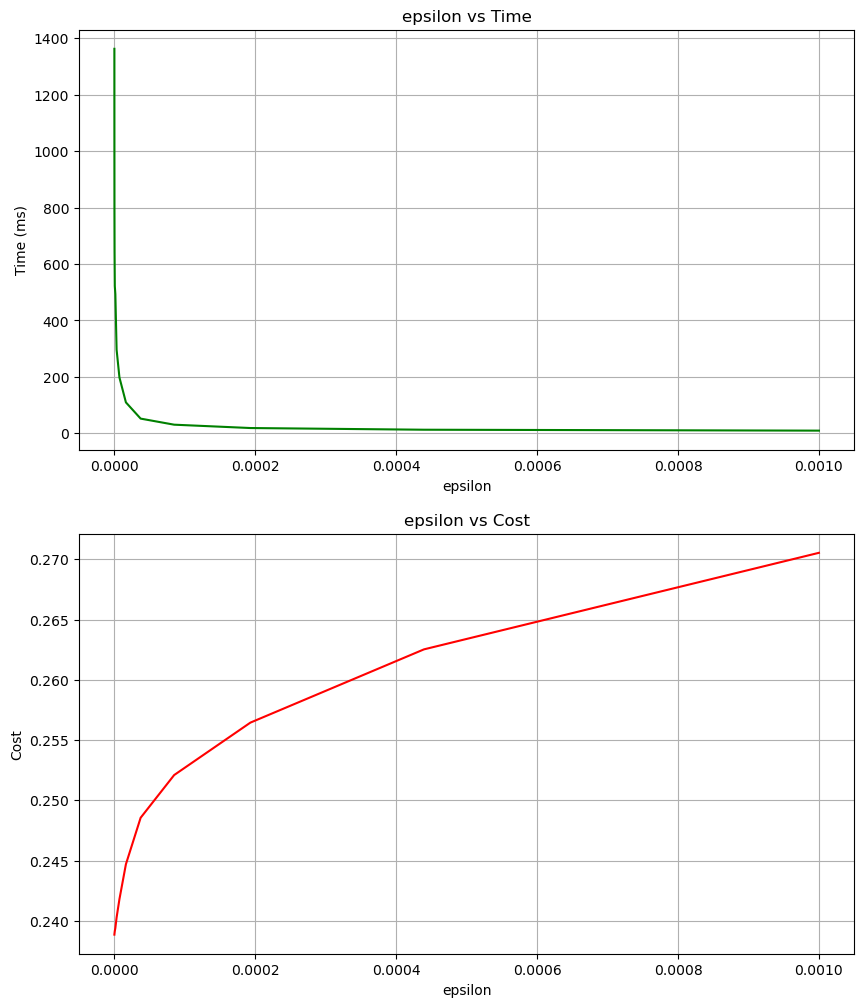

In [19]:
gradient_descent_tuning(training_X, training_targets, np.logspace(-3, -8, num=15), 3, 'E', gradient_descent, 50000 )

## Gradient Descent Convergence

In [4]:
ALPHA = 3
EPSILON = 6e-7
initial_params = np.zeros(shape=(training_X.shape[1] + 1))

In [5]:
training_X_with_bias = training_X.to_numpy()
training_X_with_bias = np.column_stack( ( np.ones(training_X_with_bias.shape[0]), training_X_with_bias) )
parameters, iters_costs = gradient_descent(training_X_with_bias, training_targets, ALPHA, EPSILON, initial_params, 5000)

Converged at iteration 1575.


In [6]:
iters_costs

{1: 0.3856743483535915,
 2: 0.3440049658710229,
 3: 0.32714130203688535,
 4: 0.31607920639899195,
 5: 0.3079919569508617,
 6: 0.3017802669917768,
 7: 0.29681678547742124,
 8: 0.29271665287211446,
 9: 0.2892611940400347,
 10: 0.2863110221829639,
 11: 0.2837666020887128,
 12: 0.2815512998637916,
 13: 0.27960458369024765,
 14: 0.27787883443223216,
 15: 0.276336752502022,
 16: 0.2749489867694753,
 17: 0.27369220097484753,
 18: 0.2725476165274812,
 19: 0.2714999444993476,
 20: 0.27053660308173977,
 21: 0.26964713790496836,
 22: 0.2688227865389705,
 23: 0.2680561466938464,
 24: 0.26734092013555427,
 25: 0.2666717127617614,
 26: 0.2660438768254731,
 27: 0.2654533852722253,
 28: 0.26489673074640835,
 29: 0.2643708438408119,
 30: 0.2638730262876362,
 31: 0.2634008961527029,
 32: 0.2629523423697542,
 33: 0.26252548715044205,
 34: 0.26211865420612923,
 35: 0.2617303423402814,
 36: 0.26135920277537594,
 37: 0.26100402028760217,
 38: 0.26066369667293093,
 39: 0.2603372370688216,
 40: 0.260023737484

In [6]:
parameters

array([-3.48826172, -4.25053597, -4.75350418,  0.52172463,  0.4194263 ,
        0.57240839,  0.19251383,  0.82939614,  0.07002128, -3.51411254,
        2.7582142 ,  2.19620859,  0.15765323,  0.41574311, -0.32420111,
        0.29992872])

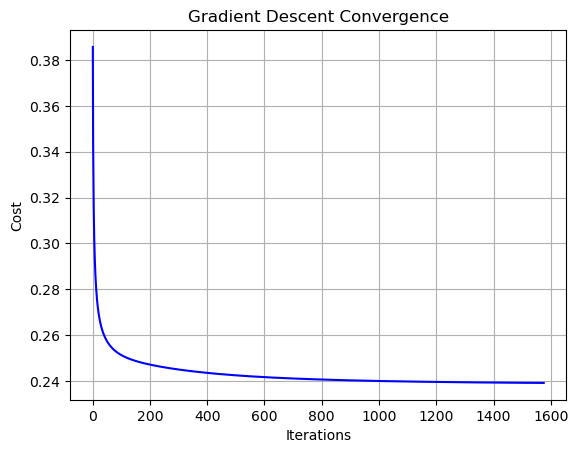

In [7]:
gradient_descent_convergence(iters_costs.keys(), iters_costs.values())

## Predict for the training and testing datasets

In [7]:
training_predicitons = logistic_function(training_X_with_bias, parameters)
training_error_rate = compute_cost(training_predicitons, training_targets)

In [8]:
testing_X_with_bias = testing_X.to_numpy()
testing_X_with_bias = np.column_stack( ( np.ones(testing_X_with_bias.shape[0]), testing_X_with_bias) )
testing_predicitons = logistic_function(testing_X_with_bias, parameters)
testing_error_rate = compute_cost(testing_predicitons, testing_targets)

In [9]:
print("The Training Error Rate is: ", training_error_rate)
print("The Testing Error Rateis: ", testing_error_rate)

The Training Error Rate is:  0.23915130283272612
The Testing Error Rateis:  0.32429673800891484


In [9]:
# Store the parameters
store = {
    'parameters': list(parameters)
}
with open("../cache/logistic_regression.pkl", 'wb') as f:
    pickle.dump(store, f)